# Body Fat Percentage Prediction Project

This notebook walks through a complete data science workflow focused on predicting body fat percentage using anthropometric data. It includes:

- Data loading and cleaning
- Exploratory data analysis (EDA)
- Feature selection and multicollinearity checks
- Multiple regression modeling (OLS, Ridge, Lasso)
- Decision Tree Regression
- Model comparison and interpretation
- Residual and diagnostics analysis




In [4]:
# Import necessary libraries for data analysis and modeling
import pandas as pd  # for data manipulation
import numpy as np  # for numerical operations
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns  # for advanced visualization

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Configure display options
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


In [5]:
# Import necessary libraries
import pandas as pd

# Load the dataset from the specified absolute path
df = pd.read_csv(
    r'/Users/kevinegemba/Library/CloudStorage/OneDrive-Personal/Datascience Masters/DS (Fall 2024) SEMESTER 1/DX602 O1 Module 2 Programming Toolkit for Data Science (Fall 2024)/Final Project/final-project-Kevin-Egemba/560_bodyfat.csv',
    sep=','
)

# Drop any rows with missing values to ensure data integrity
df = df.dropna()

# Display a random sample of 10 rows from the cleaned dataset
random_sample = df.sample(10, random_state=42)
print(random_sample)


     Density   Age  Weight  Height       Neck       Chest     Abdomen  \
165   1.0549  35.0  217.00   73.75  40.500000  107.500000   95.099998   
6     1.0549  26.0  181.00   69.75  36.400002  105.099998   90.699997   
111   1.0355  43.0  183.25   70.00  37.099998  108.000000  105.000000   
172   1.0521  35.0  177.25   71.00  38.400002  100.500000   90.300003   
115   1.0607  40.0  158.00   69.25  36.299999   97.000000   86.599998   
183   1.0713  40.0  159.25   69.75  35.299999   92.300003   86.800003   
199   1.0462  43.0  170.75   67.50  37.400002  103.699997   89.699997   
235   1.0563  62.0  168.75   67.50  38.299999  104.699997   95.599998   
9     1.0722  23.0  198.25   73.50  42.099998   99.599998   88.599998   
30    1.0716  32.0  182.00   73.75  38.700001  100.500000   88.699997   

            Hip      Thigh       Knee      Ankle     Biceps    Forearm  \
165  104.500000  64.800003  41.299999  25.600000  36.400002  33.700001   
6    100.300003  58.400002  38.299999  22.900000

In [6]:
# Check for missing values and general data information
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   Age      252 non-null    float64
 2   Weight   252 non-null    float64
 3   Height   252 non-null    float64
 4   Neck     252 non-null    float64
 5   Chest    252 non-null    float64
 6   Abdomen  252 non-null    float64
 7   Hip      252 non-null    float64
 8   Thigh    252 non-null    float64
 9   Knee     252 non-null    float64
 10  Ankle    252 non-null    float64
 11  Biceps   252 non-null    float64
 12  Forearm  252 non-null    float64
 13  Wrist    252 non-null    float64
 14  target   252 non-null    float64
dtypes: float64(15)
memory usage: 29.7 KB


,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,target
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,44.884921,178.924405,70.148810,37.992064,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762,19.150794
std,0.019031,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411804,1.694894,3.021274,2.020691,0.933585,8.368740
min,0.995000,22.000000,118.500000,29.500000,31.100000,79.300003,69.400002,85.000000,47.200001,33.000000,19.100000,24.799999,21.000000,15.800000,0.000000
25%,1.041400,35.750000,159.000000,68.250000,36.400002,94.350000,84.574999,95.500000,56.000000,36.975000,22.000000,30.200001,27.299999,17.600000,12.475000
50%,1.054900,43.000000,176.500000,70.000000,38.000000,99.649998,90.950001,99.300003,59.000000,38.500000,22.799999,32.049999,28.700001,18.299999,19.200001
75%,1.070400,54.000000,197.000000,72.250000,39.425001,105.375002,99.324997,103.525000,62.349999,39.925001,24.000000,34.325000,30.000000,18.799999,25.299999
max,1.108900,81.000000,363.149994,77.750000,51.200001,136.199997,148.100006,147.699997,87.300003,49.099998,33.900002,45.000000,34.900002,21.400000,47.500000


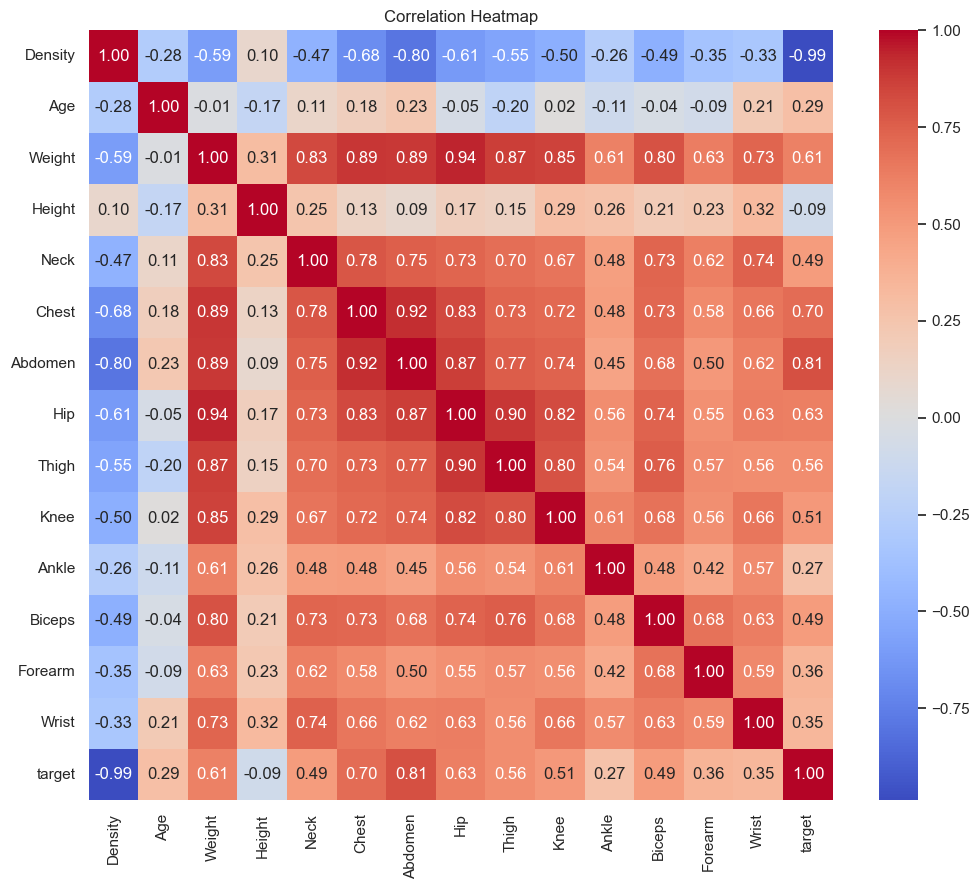

In [7]:
# Correlation matrix to inspect linear relationships between features and target
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [9]:
# Define the target and features
X = df.drop(columns=['target'])
y = df['target']

# Standardize features before calculating VIF
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Calculate Variance Inflation Factor (VIF)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
vif_data.sort_values("VIF", ascending=False)


,Feature,VIF
2,Weight,34.031689
6,Abdomen,18.119892
7,Hip,14.960949
5,Chest,9.472237
8,Thigh,7.887713
9,Knee,4.612290
4,Neck,4.396475
0,Density,3.818258
11,Biceps,3.651610
13,Wrist,3.521509


In [10]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
# Fit a Multiple Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict and evaluate
y_pred_lr = lr.predict(X_test)
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:", mean_squared_error(y_test, y_pred_lr, squared=False))


Linear Regression R²: 0.9918244709722297
Linear Regression RMSE: 0.6166926603486863


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [12]:
# Fit Ridge and Lasso models
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

# Predictions
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

# Evaluation
print("Ridge R²:", r2_score(y_test, y_pred_ridge))
print("Ridge RMSE:", mean_squared_error(y_test, y_pred_ridge, squared=False))

print("Lasso R²:", r2_score(y_test, y_pred_lasso))
print("Lasso RMSE:", mean_squared_error(y_test, y_pred_lasso, squared=False))


Ridge R²: 0.6274057775570134
Ridge RMSE: 4.163215630039682
Lasso R²: 0.6125711205161335
Lasso RMSE: 4.245284914732139


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [13]:
# Fit a Decision Tree Regressor
tree = DecisionTreeRegressor(random_state=42, max_depth=4)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Decision Tree R²:", r2_score(y_test, y_pred_tree))
print("Decision Tree RMSE:", mean_squared_error(y_test, y_pred_tree, squared=False))


Decision Tree R²: 0.9742696688054533
Decision Tree RMSE: 1.0940408427730741


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


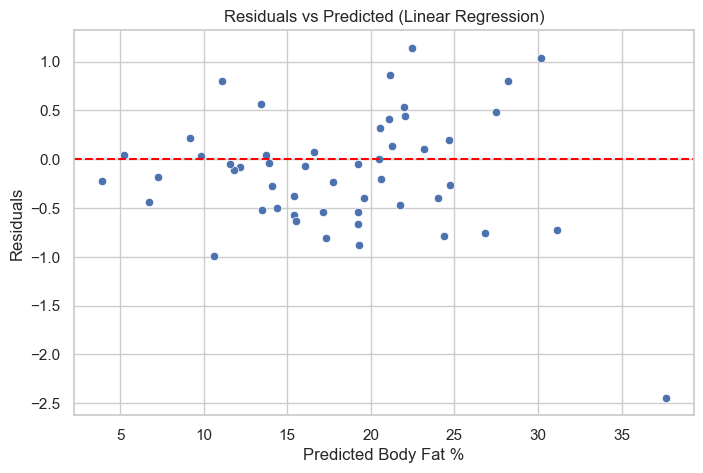

In [14]:
# Residual plot for linear regression
residuals = y_test - y_pred_lr
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_lr, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Body Fat %")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Linear Regression)")
plt.show()
